In [1]:
# 데이터 분석/모델링에 필요한 라이브러리 임포트 + 그래프 한글 폰트 설정
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 타이타닉 CSV 경로를 조립해서 데이터프레임으로 불러오기
base_path = r"E:\kdt_0900_sal\ml\resource\dataset"
file_name = r"titanic.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
# 예측에 쓸모 없는 컬럼(식별자, 이름, 티켓번호, 결측 많은 Cabin 등) 제거
drop_column = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_column, axis=1)

## 1. 데이터 전처리

In [4]:
# 컬럼별 자료형과 결측치 개수 확인
# 수치형: SibSp, Age, Parch, Fare
# 분류형: Survived, Pclass, Sex
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [5]:
# 수치형 컬럼의 기초 통계(개수, 평균, 표준편차, 사분위수) 확인
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


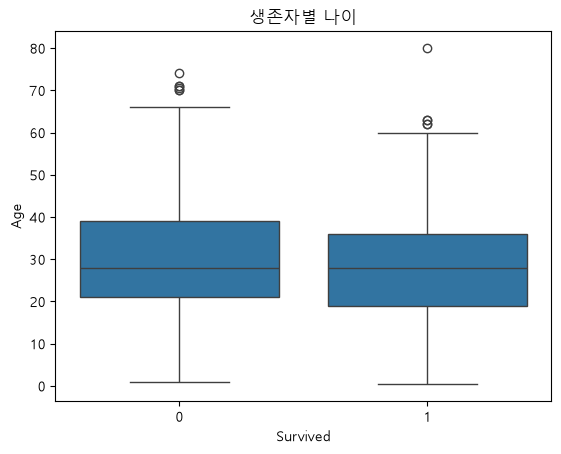

In [6]:
# 생존 여부에 따라 나이 분포가 어떻게 다른지 박스플롯으로 비교
sns.boxplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")
plt.show()

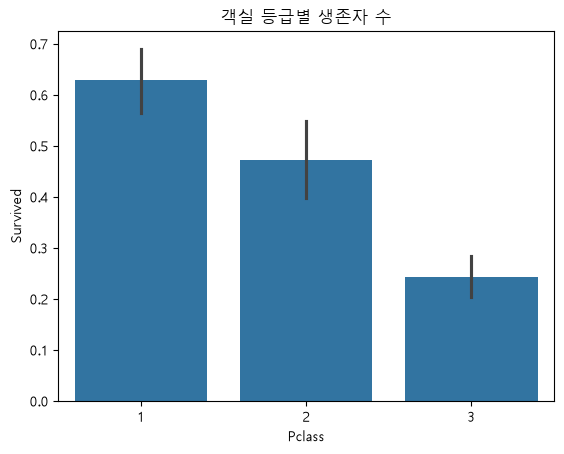

In [7]:
# 객실 등급별 평균 생존율을 막대그래프로 비교
sns.barplot(titanic_df, x="Pclass", y="Survived")
plt.title("객실 등급별 생존자 수")
plt.show()

In [8]:
# Age 결측치를 평균값으로 채우고 정수형으로 바꾼 뒤, 결측이 사라졌는지 확인
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean())
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


## 원 핫 인코딩(one-hot encoding)
- 글자나 범주형(분류형) 데이터를 컴퓨터가 좋아하는 0과 1의 행열구조로 변환하는 전처리 기술이다.

In [9]:
# 문자열인 성별(male/female)을 모델이 읽을 수 있게 0/1로 인코딩
titanic_df["Sex"] = titanic_df["Sex"].astype(str)
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df["Sex"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64

In [10]:
# 전처리가 제대로 됐는지 상위 5행만 확인
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22,1,0,7.2500
1,1,1,1,38,1,0,71.2833
2,1,3,1,26,0,0,7.9250
3,1,1,1,35,1,0,53.1000
4,0,3,0,35,0,0,8.0500


## 파생변수

In [11]:
# 파생변수 생성: FamilySize = 형제·배우자 + 부모·자녀 + 본인 1명
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,2
2,1,3,1,26,0,0,7.9250,1
3,1,1,1,35,1,0,53.1000,2
4,0,3,0,35,0,0,8.0500,1


## ※상관관계 분석 및 다중공선성

In [12]:
# 수치형 컬럼끼리의 상관계수 행렬 계산
corr_matrix = titanic_df.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,0.543351,-0.067809,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.131900,-0.335071,0.083081,0.018443,-0.549500,0.065997
Sex,0.543351,-0.131900,1.000000,-0.082533,0.114631,0.245489,0.182333,0.200988
Age,-0.067809,-0.335071,-0.082533,1.000000,-0.232743,-0.176744,0.093856,-0.247370
SibSp,-0.035322,0.083081,0.114631,-0.232743,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,0.245489,-0.176744,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.182333,0.093856,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,0.200988,-0.247370,0.890712,0.783111,0.217138,1.000000


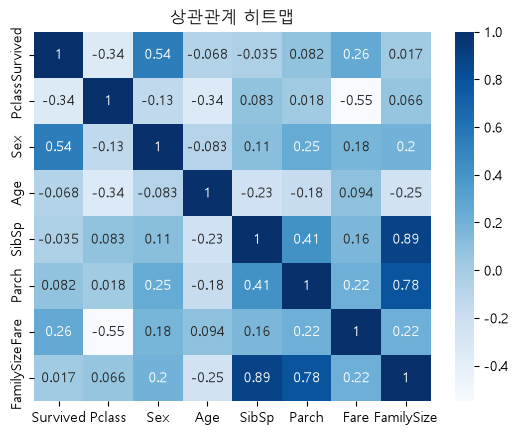

In [13]:
# 상관계수 행렬을 히트맵으로 시각화 (annot=True로 셀에 숫자 표시)
sns.heatmap(corr_matrix, cmap="Blues", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [14]:
# 다중공선성 진단용 VIF 계산 함수 임포트
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
# 정답 컬럼(Survived)을 뺀 나머지를 독립변수 X로 분리
X = titanic_df.drop("Survived", axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,3,0,22,1,0,7.2500,2
1,1,1,38,1,0,71.2833,2
2,3,1,26,0,0,7.9250,1
3,1,1,35,1,0,53.1000,2
4,3,0,35,0,0,8.0500,1
...,...,...,...,...,...,...,...
886,2,0,27,0,0,13.0000,1
887,1,1,19,0,0,30.0000,1
888,3,1,29,1,2,23.4500,4
889,1,0,26,0,0,30.0000,1


In [16]:
# 예측 대상인 Survived를 종속변수 y로 분리
y = titanic_df["Survived"]
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [17]:
# 컬럼별 VIF 계산 - 값이 크면 그 변수가 다른 변수들로 설명된다는 뜻
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

C:\Users\fdsa0\AppData\Local\Temp\ipykernel_10592\3456959893.py:2: UserWarning: The design matrix is poorly conditioned (condition number=4.95e+15). VIF calculations may be numerically unstable.
  vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
C:\Users\fdsa0\.conda\envs\machine_learning\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\fdsa0\.conda\envs\machine_learning\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\fdsa0\.conda\envs\machine_learning\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determin

[np.float64(1.6744625546476168),
 np.float64(1.0999477030456601),
 np.float64(1.2074005137492676),
 np.float64(1000799917193443.5),
 np.float64(1000799917193443.5),
 np.float64(1.5927996156293964),
 np.float64(1000799917193443.5)]

## VIF
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다.
- 즉 독립변수와 독립변수와의 관계를 의미하며 다른 변수들과의 조합을 수치로 표현한 것이다.

### VIF 해석
- VIF < 5: 문제없음
- 5 <= VIF <= 10: 주의
- VIF > 10: 다중 공선성 의심(조치, 삭제, 고려)

In [18]:
# SibSp, Parch는 FamilySize와 정보가 겹치므로(다중공선성) 제거
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis=1)

In [19]:
# 컬럼을 정리했으니 독립변수 X를 다시 만들기
X = titanic_df.drop("Survived", axis=1)

In [20]:
# 종속변수 y도 다시 만들기
y = titanic_df["Survived"]

In [21]:
# 컬럼 제거 후 VIF 재계산 - 값이 내려갔는지 확인
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize'], dtype='str')


[np.float64(1.6743819682616452),
 np.float64(1.0794219842460373),
 np.float64(1.2065529011311142),
 np.float64(1.589318305130038),
 np.float64(1.1915806348327602)]

In [22]:
# 학습:테스트 = 8:2 분할. stratify=y로 생존 비율을 양쪽에 똑같이 유지하고, random_state로 분할 결과 고정
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 5) (179, 5) (712,) (179,)


In [23]:
# 컬럼마다 단위가 달라서 표준화. 기준은 학습 데이터로만 fit하고 테스트는 transform만 (데이터 누수 방지)
# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. 모델 준비

In [24]:
# 로지스틱 회귀 모델 임포트
from sklearn.linear_model import LogisticRegression

In [25]:
# 모델 객체 생성 (기본 하이퍼파라미터 그대로)
lr = LogisticRegression()

## 3. 모델 학습

In [26]:
# 학습 데이터로 모델 학습 - 각 컬럼의 가중치를 찾는 단계
lr.fit(X_train_scaled, y_train)

LogisticRegression()

## 4. 모델 평가

In [27]:
# 학습 정확도와 테스트 정확도 비교. 둘 차이가 크면 과적합 의심
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

print(train_score)
print(test_score)

0.8061797752808989
0.7821229050279329


### 시그모이드 함수 (Sigmoid Function)
수학자들이 만든 특수한 함수로, 여기에 어떤 숫자를 넣든 무조건 **0과 1 사이의 소수점(확률)**으로 꽉 눌러서 변환해 줍니다.

$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fsib2q%2FbtsDJkfaBMy%2FAAAAAAAAAAAAAAAAAAAAAJwQd20TZhIxLx58GiUJdYxCLH_4xkSt66vEea-TnEkx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZyqh5kd4SOqkuF96VWHHU3%252B91F0%253D)

In [28]:
# 테스트 데이터에 대한 예측값(0=사망, 1=생존) 생성
y_pred = lr.predict(X_test_scaled)

In [29]:
# 예측 확률 / 예측값 / 실제 정답을 앞 5개만 나란히 비교
# 주의: predict_proba()는 넘파이 배열이라 .head()가 없음 -> 마지막 줄은 에러. [:5] 등으로 슬라이싱해야 함
print(f"모델의 예측 확률: {lr.predict_proba(X_test_scaled)[:5]}")
print(f"모델의 예측 값: {y_pred[:5]}")
print(f"모델의 정답: {y_test.values[:5]}")

# lr.predict_proba(X_test_scaled).head()

모델의 예측 확률: [[0.88867611 0.11132389]
 [0.95189906 0.04810094]
 [0.04468729 0.95531271]
 [0.88506978 0.11493022]
 [0.90039734 0.09960266]]
모델의 예측 값: [0 0 1 0 0]
모델의 정답: [0 0 1 0 0]


In [30]:
# 정확도 출력. score()와 accuracy_score()가 같은 값을 주는지 확인
# 주의: 첫 줄은 X_train_scaled라서 실제로는 '학습' 정확도 (문구와 다름)
print(f"테스트 정확도: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도: {accuracy_score(y_pred=y_pred, y_true=y_test)}")

테스트 정확도: 0.8061797752808989
테스트 정확도: 0.7821229050279329


## ROC-Curve
- 이진 분류 모델의 성능을 임계값을 기준엣 시각적으로 평가한 그래프이다.
- x축(특이도) - TPR: 실제 양성인데 모델이 양성이라 예측한 비율
- y축(민감도) - FPR: 실제 음성인데 모델이 양성이라 예측한 비율

In [31]:
# ROC 곡선 시각화 클래스 임포트
from sklearn.metrics import RocCurveDisplay

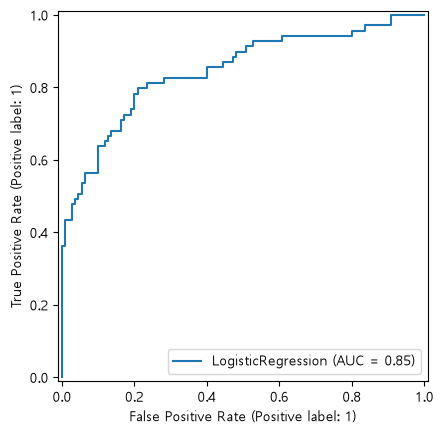

In [32]:
# 테스트 데이터로 ROC 곡선과 AUC 값 확인
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

In [33]:
# 컬럼별 회귀계수(가중치)를 표로 정리하고 큰 값 순으로 정렬
# 각 가중치
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef",ascending=False)
lr.coef_[0]

array([-0.90987823,  1.3345076 , -0.50931766,  0.15320702, -0.31641659])

In [34]:
# 정렬된 가중치 표 확인
coef_df

,Features,Coef
1,Sex,1.334508
3,Fare,0.153207
4,FamilySize,-0.316417
2,Age,-0.509318
0,Pclass,-0.909878


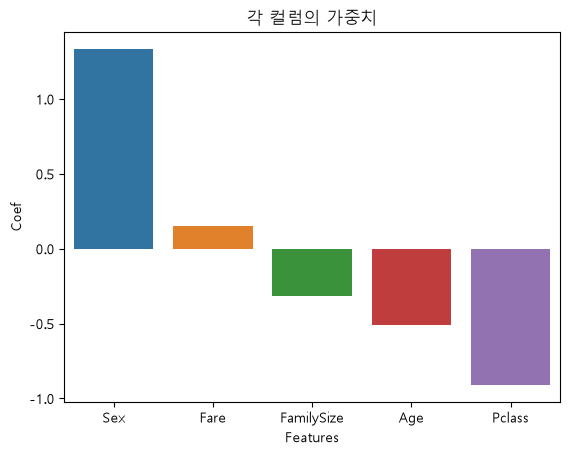

In [35]:
# 컬럼별 가중치를 막대그래프로 - 계수 부호가 생존 확률에 미치는 방향을 읽는 단계
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")
plt.show()

"""
    성별(Sex)은 양의 상관관계 가진다. 즉 성별이 1(female)일수록 생존확률 높다(1).
    객실 등급(Pclass)는 음의 상관관계를 가진다. 즉 객실 등급이 높을수록(숫자가 작을 수록) 생존확률이 높다(1).
"""
None

In [36]:
# 실제 정답과 예측이 다른 케이스(틀린 샘플)만 골라서 확인
wrong_cases = X_test[y_test != y_pred]
wrong_cases.head()

,Pclass,Sex,Age,Fare,FamilySize
400,3,0,39,7.9250,1
593,3,1,29,7.7500,3
630,1,0,80,30.0000,1
569,3,0,32,7.8542,1
271,3,0,25,0.0000,1


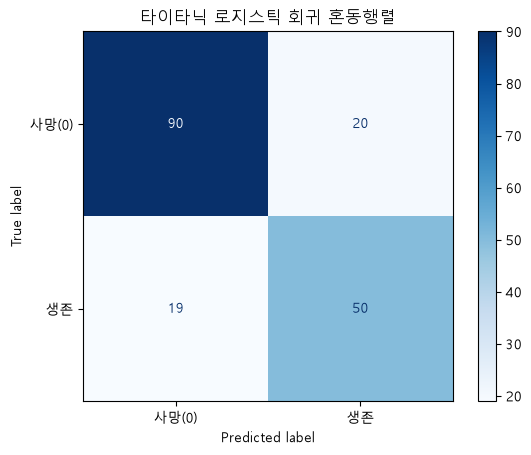

In [37]:
# 혼동행렬 시각화 - 사망/생존을 각각 얼마나 맞히고 틀렸는지 확인
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    display_labels=["사망(0)","생존"],
    cmap="Blues"
)

plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()

In [38]:
# 정밀도·재현율·F1 등 분류 리포트 출력
# 주의: 인자 순서는 (y_true, y_pred)가 맞음 -> classification_report(y_test, y_pred)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       109
           1       0.72      0.71      0.72        70

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

